# **Audio Classification with Deep Learning**

---



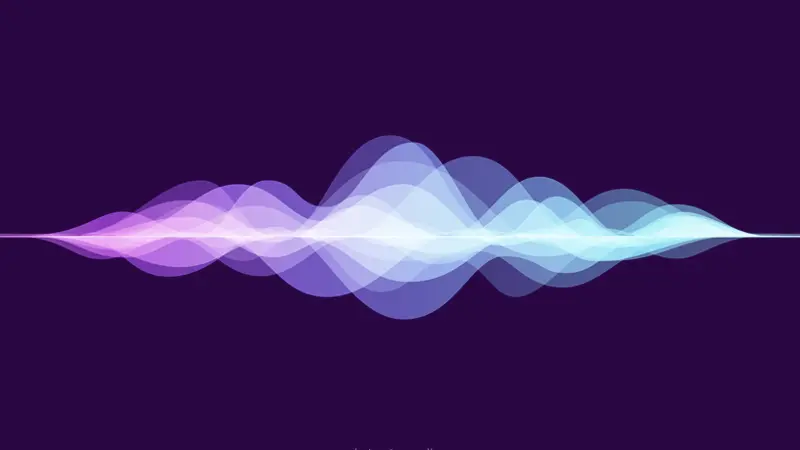

#**Business Understanding**


---


####*Background*

Urban areas generate many different sounds every day, such as car horns, sirens, dog barking, drilling, street music, and engine noises. Monitoring and identifying these sounds manually is difficult, time-consuming, and expensive.

With the growth of smart cities and intelligent monitoring systems, there is a need for automated solutions that can accurately recognize and classify urban sounds in real time.

#**Business Problem**

---



Organizations responsible for public safety, environmental monitoring, and smart city management often struggle to monitor urban sound events continuously.

Important sounds such as emergency sirens, gunshots, or construction noise may require immediate attention, but manual monitoring is not practical.

The challenge is to develop an intelligent system that can automatically identify different urban sound categories from audio recordings.

#**Problem Statement**

---





Can we build a deep learning model that accurately classifies urban audio recordings into one of the following ten sound categories?

* Air Conditioner
* Car Horn
* Children Playing
* Dog Bark
* Drilling
* Engine Idling
* Gun Shot
* Jackhammer
* Siren
* Street Music

#**Objectives**

---



## Main Objective:

Develop a Convolutional Neural Network (CNN) model capable of classifying urban sounds based on audio recordings.

### Specific Objectives:

* Load and explore the UrbanSound8K dataset.
* Convert raw audio signals into Mel-Spectrogram representations.
* Perform feature extraction using Librosa.
* Train a CNN model on spectrogram images.
* Evaluate model performance using classification metrics.
* Build a system capable of predicting sound categories from unseen audio files.

## Stakeholders

The project may benefit:

* Smart City Authorities
* Environmental Monitoring Agencies
* Public Safety Departments
* Traffic Management Authorities
* Security Organizations
* Researchers in Audio Analytics

## Business Impact

A successful solution can:

✅ Improve public safety

✅ Detect emergency situations faster

✅ Reduce manual monitoring costs

✅ Support smart city initiatives

✅ Enable automated urban noise monitoring

## Success Metrics

---



The project will be considered successful if the model achieves:

* High Classification Accuracy
* High Precision
* High Recall
* High F1 Score
* Strong performance across all 10 sound classes

## Analytical Questions

* Which sound classes have the highest number of recordings?  
* Is the dataset balanced across classes?  
* Does salience affect classification performance?  
* Which classes are most frequently confused by the model?  
* What overall accuracy can be achieved using CNNs?

##**Machine Learning Approach**


---



####Type of Problem

`Multi-Class Classification`

####Input

`Audio recordings (.wav)`

####Feature Engineering

`Audio → Mel-Spectrogram`

####Model

`Convolutional Neural Network (CNN)`

####Output

`Predicted Sound Class`

Example:

Input: audio.wav

Prediction: Siren
Confidence: 96%

#**Data Preparation**

---



Before building the machine learning model, the dataset must be prepared and transformed into a format suitable for analysis and modeling.

# Data Understanding


---


## Dataset Overview

Dataset Name: `UrbanSound8K`

Dataset Size:

* `8,732 audio files`
* `WAV format`
* `10 sound categories`

***Target Variable:***

class

Examples:

siren  
dog_bark  
car_horn  
drilling  
gun_shot




***Important Features:***

fold  
classID  
class  
salience  
start  
end

#**Feature Description**


---


###*slice_file_name*

Unique audio filename.

Example:

100032-3-0-0.wav

###*fsID*

Unique Freesound recording identifier.

Purpose:

Identifies the original source recording.

###*start*

Starting timestamp of the audio slice within the original recording.

###*end*

Ending timestamp of the audio slice.

###*salience*

Indicates the prominence of the sound.

Value	Meaning

1. Foreground Sound
2. Background Sound

###*classID*

Numeric label assigned to each sound category.

Class ID	Sound Category
0. air_conditioner
1. car_horn
2. children_playing
3. dog_bark
4. drilling
5. engine_idling
6. gun_shot
7. jackhammer
8. siren
9. street_music

###*class (Target Variable)*

Represents the sound category the model will predict.

Examples:

- dog_bark
- siren
- drilling
- gun_shot

###*Target Variable Analysis*

This project is a `Multi-Class Classification Problem`.


The model's objective is to predict the correct sound category from the audio recording.

In [ ]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Audio processing
import librosa
import librosa.display

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.layers import BatchNormalization



In [ ]:
df = pd.read_csv('data/UrbanSound8K.csv')

df.head()

,slice_file_name,fsID,start,end,salience,fold,classID,class
0,100032-3-0-0.wav,100032,0.0,0.317551,1,5,3,dog_bark
1,100263-2-0-117.wav,100263,58.5,62.500000,1,5,2,children_playing
2,100263-2-0-121.wav,100263,60.5,64.500000,1,5,2,children_playing
3,100263-2-0-126.wav,100263,63.0,67.000000,1,5,2,children_playing
4,100263-2-0-137.wav,100263,68.5,72.500000,1,5,2,children_playing


In [ ]:
import sys
!{sys.executable} -m pip install --user librosa

  Using cached librosa-0.11.0-py3-none-any.whl (260 kB)
  Using cached scikit_learn-1.3.2-cp38-cp38-win_amd64.whl (9.3 MB)
  Using cached audioread-3.0.1-py3-none-any.whl (23 kB)
  Using cached numba-0.58.1-cp38-cp38-win_amd64.whl (2.6 MB)
  Using cached pooch-1.8.2-py3-none-any.whl (64 kB)
  Using cached soundfile-0.13.1-py2.py3-none-win_amd64.whl (1.0 MB)
  Using cached llvmlite-0.41.1-cp38-cp38-win_amd64.whl (28.1 MB)
  Using cached platformdirs-4.3.6-py3-none-any.whl (18 kB)


In [ ]:
import librosa
import librosa.display
print(librosa.__version__)

0.11.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8732 entries, 0 to 8731
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   slice_file_name  8732 non-null   object 
 1   fsID             8732 non-null   int64  
 2   start            8732 non-null   float64
 3   end              8732 non-null   float64
 4   salience         8732 non-null   int64  
 5   fold             8732 non-null   int64  
 6   classID          8732 non-null   int64  
 7   class            8732 non-null   object 
dtypes: float64(2), int64(4), object(2)
memory usage: 545.9+ KB


In [ ]:
#Check Missing Values
df.isnull().sum()

slice_file_name    0
fsID               0
start              0
end                0
salience           0
fold               0
classID            0
class              0
dtype: int64

In [ ]:
# checking for duplicates
df.duplicated().sum()

0

In [ ]:
#Summary Statistics
df.describe()

,fsID,start,end,salience,fold,classID
count,8732.000000,8732.000000,8732.000000,8732.000000,8732.000000,8732.000000
mean,116033.493816,38.645409,42.253312,1.347000,5.385937,4.592877
std,57991.017218,74.292126,74.369669,0.476043,2.846820,2.894544
min,344.000000,0.000000,0.105962,1.000000,1.000000,0.000000
25%,69942.250000,3.000000,6.839398,1.000000,3.000000,2.000000
50%,118279.000000,10.376492,14.000000,1.000000,5.000000,4.000000
75%,166942.000000,35.131372,38.866979,2.000000,8.000000,7.000000
max,209992.000000,600.125356,604.125356,2.000000,10.000000,9.000000


## EDA (Exploratory Data Analysis)

### 1. Class Distribution

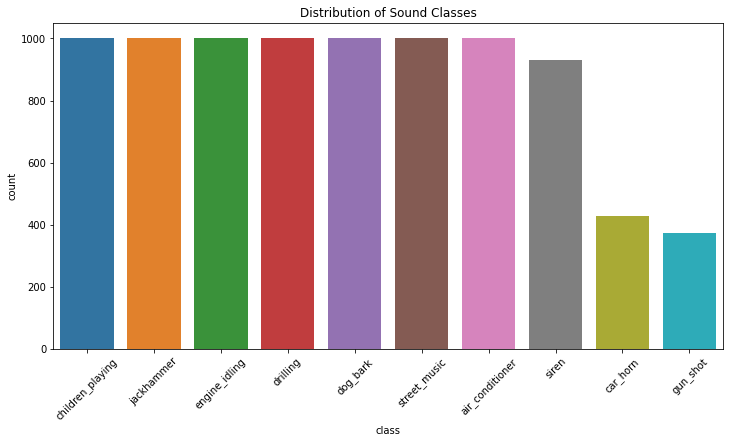

In [ ]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    x='class',
    order=df['class'].value_counts().index
)

plt.title('Distribution of Sound Classes')
plt.xticks(rotation=45)
plt.show()

### 2. Salience Distribution


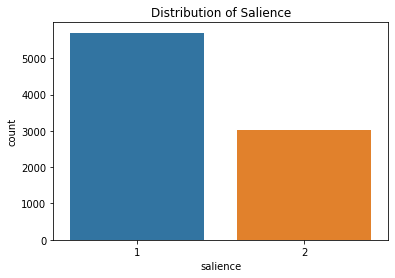

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x='salience'
)

plt.title('Distribution of Salience')
plt.show()

Shows the number of:

Foreground sounds (1)
Background sounds (2)

### 3. Class vs Salience

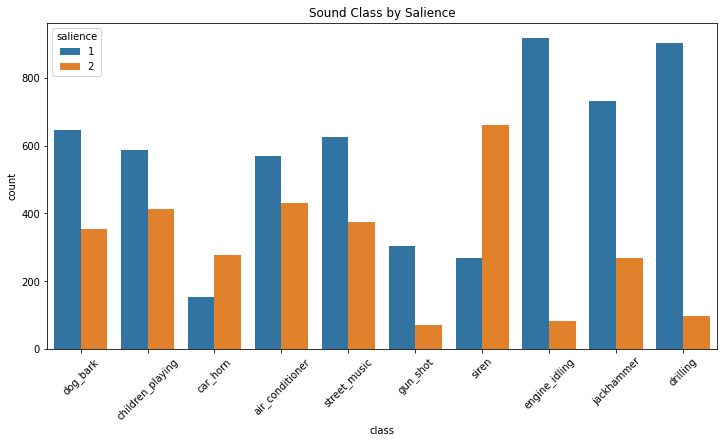

In [ ]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    x='class',
    hue='salience'
)

plt.xticks(rotation=45)
plt.title('Sound Class by Salience')
plt.show()

### 4. Fold Distribution

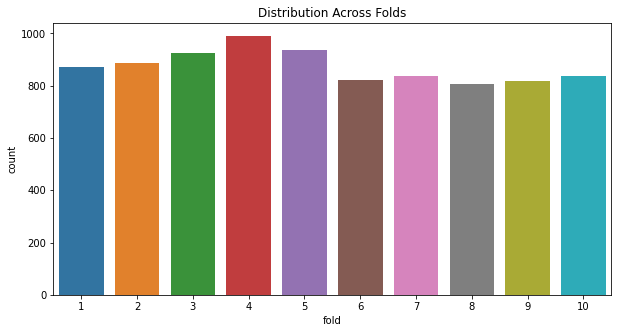

In [ ]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x='fold'
)

plt.title('Distribution Across Folds')
plt.show()

### 5. Sound Classes Across Folds

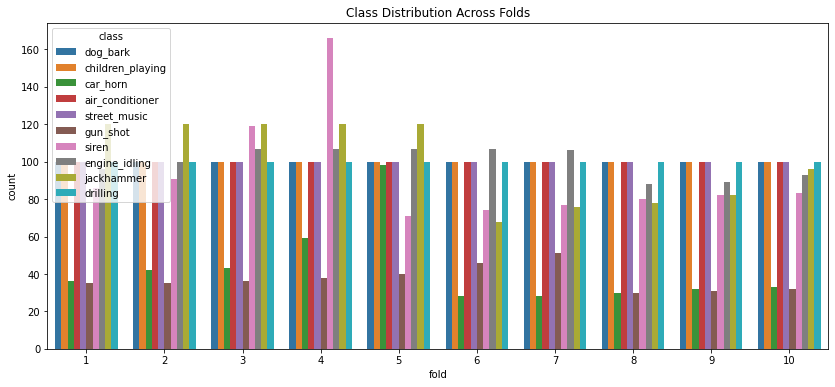

In [ ]:
plt.figure(figsize=(14,6))

sns.countplot(
    data=df,
    x='fold',
    hue='class'
)

plt.title('Class Distribution Across Folds')
plt.show()

### 5. Correlation Heatmap

In [ ]:
numeric_df = df.select_dtypes(include=['int64','float64'])

numeric_df.head()

,fsID,start,end,salience,fold,classID
0,100032,0.0,0.317551,1,5,3
1,100263,58.5,62.500000,1,5,2
2,100263,60.5,64.500000,1,5,2
3,100263,63.0,67.000000,1,5,2
4,100263,68.5,72.500000,1,5,2


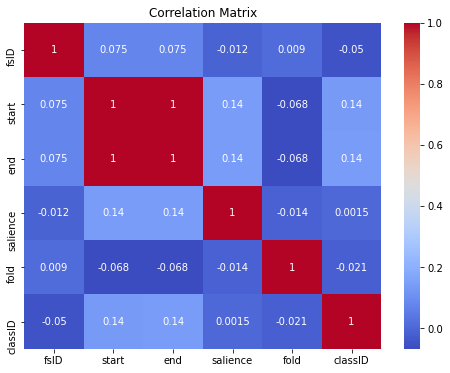

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Matrix')
plt.show()

* Goal: Automated environmental audio classification for smart city noise monitoring or public safety anomaly detection.

* Core Data Challenge: Raw acoustic data arrives as non-stationary, one-dimensional waveforms with varying temporal lengths. Standard machine learning models cannot natively extract features from raw amplitude arrays without loss of localized frequency data.

In [3]:
# 1. Install the latest Kaggle CLI client
!pip install --upgrade -q kaggle

# 2. Create the hidden .kaggle directory and save your specific access token
!mkdir -p ~/.kaggle
!echo "KGAT_e28b733576ab116600ea7d7523136ebb" > ~/.kaggle/access_token
!chmod 600 ~/.kaggle/access_token

# 3. Download UrbanSound8K directly to the cloud instance
!kaggle datasets download -d chrisfilo/urbansound8k

# 4. Unzip the downloaded file
import zipfile
import os

print("Unzipping files... this takes about 30 seconds.")
with zipfile.ZipFile("urbansound8k.zip", 'r') as zip_ref:
    zip_ref.extractall("./urbansound8k")
print("Done! Let's check the contents:")
print(os.listdir("./urbansound8k"))

Dataset URL: https://www.kaggle.com/datasets/chrisfilo/urbansound8k
License(s): Attribution-NonCommercial 4.0 International (CC BY-NC 4.0)
urbansound8k.zip: Skipping, found more recently modified local copy (use --force to force download)
Unzipping files... this takes about 30 seconds.
Done! Let's check the contents:
['fold3', 'UrbanSound8K.csv', 'fold1', 'fold7', 'fold4', 'fold5', 'fold6', 'fold2', 'fold8', 'fold9', 'fold10']


Metadata Sample:
      slice_file_name  fold             class
0    100032-3-0-0.wav     5          dog_bark
1  100263-2-0-117.wav     5  children_playing
2  100263-2-0-121.wav     5  children_playing
3  100263-2-0-126.wav     5  children_playing
4  100263-2-0-137.wav     5  children_playing

Loading sample file: ./urbansound8k/fold5/100032-3-0-0.wav (Class: dog_bark)


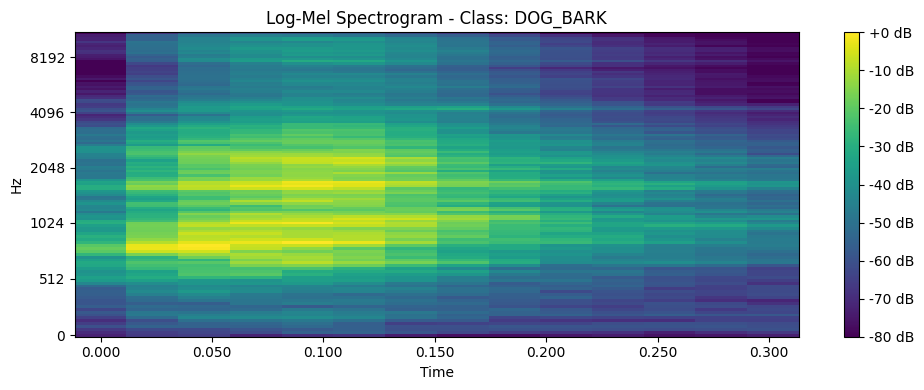

In [4]:
import os
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

# 1. Load the metadata CSV to find file paths and labels
csv_path = "./urbansound8k/UrbanSound8K.csv"
df = pd.read_csv(csv_path)

# Let's peek at the first few rows to verify it loaded
print("Metadata Sample:")
print(df[['slice_file_name', 'fold', 'class']].head())

# 2. Pick a specific row to visualize (e.g., index 0)
sample_row = df.iloc[0]
filename = sample_row['slice_file_name']
fold = sample_row['fold']
sound_class = sample_row['class']

# 3. Construct the exact path to the file inside the cloud instance
# Example target path: ./urbansound8k/fold1/100263-2-0-117.wav
audio_path = os.path.join("./urbansound8k", f"fold{fold}", filename)
print(f"\nLoading sample file: {audio_path} (Class: {sound_class})")

# 4. Load the audio signal
y, sr = librosa.load(audio_path, sr=22050)

# 5. Generate the Log-Mel Spectrogram
mel_spect = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
mel_spect_db = librosa.power_to_db(mel_spect, ref=np.max)

# 6. Plot the feature matrix
plt.figure(figsize=(10, 4))
librosa.display.specshow(mel_spect_db, sr=sr, x_axis='time', y_axis='mel', cmap='viridis')
plt.colorbar(format='%+2.0f dB')
plt.title(f'Log-Mel Spectrogram - Class: {sound_class.upper()}')
plt.tight_layout()
plt.show()

# Preprocessing & Standardization Pipeline

---

* Because the clips have different lengths, this script uses `librosa.util.fix_length` to either pad short clips with silence or trim long clips so they all result in an exact matrix shape of (128, 173).

In [5]:
import os
import numpy as np
import pandas as pd
import librosa
from tqdm import tqdm

# 1. Load metadata
csv_path = "./urbansound8k/UrbanSound8K.csv"
df = pd.read_csv(csv_path)

# Define core audio parameters
TARGET_SR = 22050          # Standardized sample rate
DURATION = 4                # Target duration in seconds
TOTAL_SAMPLES = TARGET_SR * DURATION  # 88,200 samples per clip
N_MELS = 128                # Height of our spectrogram image

def extract_features(file_path):
    """Loads an audio file, standardizes its length, and computes its Log-Mel Spectrogram"""
    try:
        # Load audio and resample
        y, sr = librosa.load(file_path, sr=TARGET_SR)

        # Standardize length: Pad with zeros if short, truncate if long
        y_fixed = librosa.util.fix_length(y, size=TOTAL_SAMPLES)

        # Generate Mel-Spectrogram
        mel_spect = librosa.feature.melspectrogram(y=y_fixed, sr=TARGET_SR, n_mels=N_MELS)

        # Convert to log scale (decibels)
        mel_db = librosa.power_to_db(mel_spect, ref=np.max)

        return mel_db
    except Exception as e:
        print(f"Error parsing {file_path}: {e}")
        return None

# 2. Lists to hold our processed data and labels
X_data = []
y_labels = []
fold_ids = []

print("Starting audio preprocessing pipeline...")
# Using a subset of 1000 rows to prototype quickly; change to df.iterrows() for full training
for idx, row in tqdm(df.head(1000).iterrows(), total=1000):
    file_name = row['slice_file_name']
    fold = row['fold']
    class_id = row['classID']

    # Construct file path
    file_path = os.path.join("./urbansound8k", f"fold{fold}", file_name)

    # Extract feature matrix
    features = extract_features(file_path)

    if features is not None:
        X_data.append(features)
        y_labels.append(class_id)
        fold_ids.append(fold)

# 3. Convert lists to NumPy arrays
X_data = np.array(X_data)
y_labels = np.array(y_labels)
fold_ids = np.array(fold_ids)

print("\n--- Pipeline Complete ---")
print(f"Features shape (Samples, Height, Width): {X_data.shape}")
print(f"Labels shape: {y_labels.shape}")

Starting audio preprocessing pipeline...


100%|██████████| 1000/1000 [00:33<00:00, 29.71it/s]



--- Pipeline Complete ---
Features shape (Samples, Height, Width): (1000, 128, 173)
Labels shape: (1000,)


## Preprocessing & Standardization Pipeline

Because audio clips have different lengths, we need to standardize them before training.  
In this project, every audio file is converted into the same duration and same shape.

Short clips are padded with silence, while long clips are trimmed.  
After that, each audio file is converted into a Log-Mel Spectrogram with shape:

**(128, 173)**

This means:
- **128** = Mel frequency bins
- **173** = time frames

# Coverting data to Pytorch Sensors

---



Before training the model, the NumPy arrays were converted into PyTorch tensors.

The CNN expects the input shape to include a channel dimension:

**(samples, channels, height, width)**

Since the spectrogram is like a grayscale image, we add one channel:

**(1000, 1, 128, 173)**

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

# 1. Add the channel dimension so shape becomes (1000, 1, 128, 173)
X_reshaped = np.expand_dims(X_data, axis=1)

# 2. Split into Train and Validation sets (80% train, 20% val)
X_train, X_val, y_train, y_val = train_test_split(
    X_reshaped, y_labels, test_size=0.2, random_state=42, stratify=y_labels
)

# 3. Convert to PyTorch float and long tensors
train_dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.long))
val_dataset = TensorDataset(torch.tensor(X_val, dtype=torch.float32), torch.tensor(y_val, dtype=torch.long))

# 4. Create DataLoaders for batching
BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

Train batches: 25 | Val batches: 7


* The model takes  (1, 128, 173) spectrogram, passes it through convolutional layers to extract audio features, downsamples it with Max Pooling, and passes it to a fully connected layer to output predictions for the 10 classes.

In [ ]:
class AudioCNN(nn.Module):
    def __init__(self):
        super(AudioCNN, self).__init__()

        # Block 1: Extracts low-level edges/features
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(16)

        # Block 2: Extracts mid-level shapes/patterns
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(32)

        # Block 3: Extracts complex audio signatures
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1)
        self.bn3 = nn.BatchNorm2d(64)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout = nn.Dropout(0.4)

        # Fully Connected Layers (Classifier Head)
        # After three MaxPool2d operations on a (128, 173) image, the feature map shrinks to (16, 21)
        self.fc1 = nn.Linear(64 * 16 * 21, 128)
        self.fc2 = nn.Linear(128, 10)  # 10 output classes

    def forward(self, x):
        # Pass through Conv -> BatchNorm -> ReLU -> MaxPooling
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))

        # Flatten the matrix into a vector for the dense layers
        x = x.view(x.size(0), -1)

        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x) # Output raw logits

        return x

# Instantiate the model and move it to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AudioCNN().to(device)
print(model)

AudioCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.4, inplace=False)
  (fc1): Linear(in_features=21504, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


To train the network, we need three things: a Loss Function (to measure how wrong the model's guesses are), an Optimizer (to adjust the weights and minimize that loss), and a Loop to iterate through our batches.

Since this is a multi-class classification problem, we will use Cross Entropy Loss and the Adam Optimizer.

In [ ]:
import torch.optim as optim

# 1. Hyperparameters & Setup
EPOCHS = 15
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(f"Training started on device: {device}\n")

# 2. Outer Loop: Iterate through Epochs
for epoch in range(EPOCHS):
    model.train()  # Set model to training mode
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    # Inner Loop: Iterate through training batches
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        # Zero out the parameter gradients from the previous step
        optimizer.zero_grad()

        # Forward pass: compute predicted outputs by passing inputs to the model
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        # Backward pass: compute gradient of the loss with respect to model parameters
        loss.backward()

        # Update weights
        optimizer.step()

        # Track statistics
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader.dataset)
    train_acc = (correct_train / total_train) * 100

    # 3. Validation Phase
    model.eval()  # Set model to evaluation mode (disables dropout/batchnorm)
    correct_val = 0
    total_val = 0
    val_loss = 0.0

    with torch.no_grad(): # Disable gradient tracking to save memory and speed up
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    epoch_val_loss = val_loss / len(val_loader.dataset)
    val_acc = (correct_val / total_val) * 100

    print(f"Epoch [{epoch+1}/{EPOCHS}] "
          f"| Train Loss: {epoch_loss:.4f} | Train Acc: {train_acc:.2f}% "
          f"| Val Loss: {epoch_val_loss:.4f} | Val Acc: {val_acc:.2f}%")

print("\nTraining Complete!")

Training started on device: cpu

Epoch [1/15] | Train Loss: 3.5196 | Train Acc: 33.50% | Val Loss: 1.5173 | Val Acc: 55.00%
Epoch [2/15] | Train Loss: 1.5049 | Train Acc: 47.75% | Val Loss: 1.1715 | Val Acc: 61.50%
Epoch [3/15] | Train Loss: 1.2925 | Train Acc: 53.62% | Val Loss: 1.1521 | Val Acc: 60.00%
Epoch [4/15] | Train Loss: 1.1978 | Train Acc: 57.75% | Val Loss: 1.0277 | Val Acc: 67.50%
Epoch [5/15] | Train Loss: 1.0446 | Train Acc: 63.62% | Val Loss: 0.8154 | Val Acc: 76.00%
Epoch [6/15] | Train Loss: 0.8777 | Train Acc: 71.12% | Val Loss: 0.6729 | Val Acc: 77.00%
Epoch [7/15] | Train Loss: 0.8219 | Train Acc: 71.50% | Val Loss: 0.6518 | Val Acc: 78.00%
Epoch [8/15] | Train Loss: 0.7314 | Train Acc: 76.62% | Val Loss: 0.6141 | Val Acc: 80.00%
Epoch [9/15] | Train Loss: 0.7090 | Train Acc: 76.12% | Val Loss: 0.5471 | Val Acc: 82.00%
Epoch [10/15] | Train Loss: 0.6392 | Train Acc: 77.88% | Val Loss: 0.5663 | Val Acc: 80.00%
Epoch [11/15] | Train Loss: 0.5772 | Train Acc: 79.88% |

In [ ]:
# Save the trained model parameters to a file
torch.save(model.state_dict(), 'audio_cnn_baseline.pth')
print("Model weights successfully saved to audio_cnn_baseline.pth")

Model weights successfully saved to audio_cnn_baseline.pth


Running this script will switch the model out of training mode, run a clean inference pass on the hidden validation data, print out a full classification report (Precision, Recall, F1-Score), and display a heatmap chart.

--- Classification Report ---
                  precision    recall  f1-score   support

 air_conditioner       1.00      0.88      0.94        17
        car_horn       0.00      0.00      0.00         2
children_playing       1.00      0.33      0.50        12
        dog_bark       0.87      1.00      0.93        27
        drilling       0.64      0.94      0.76        17
   engine_idling       0.96      0.98      0.97        49
        gun_shot       0.00      0.00      0.00         1
      jackhammer       1.00      1.00      1.00        28
           siren       0.78      0.96      0.86        26
    street_music       0.93      0.67      0.78        21

        accuracy                           0.89       200
       macro avg       0.72      0.68      0.67       200
    weighted avg       0.89      0.89      0.87       200



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


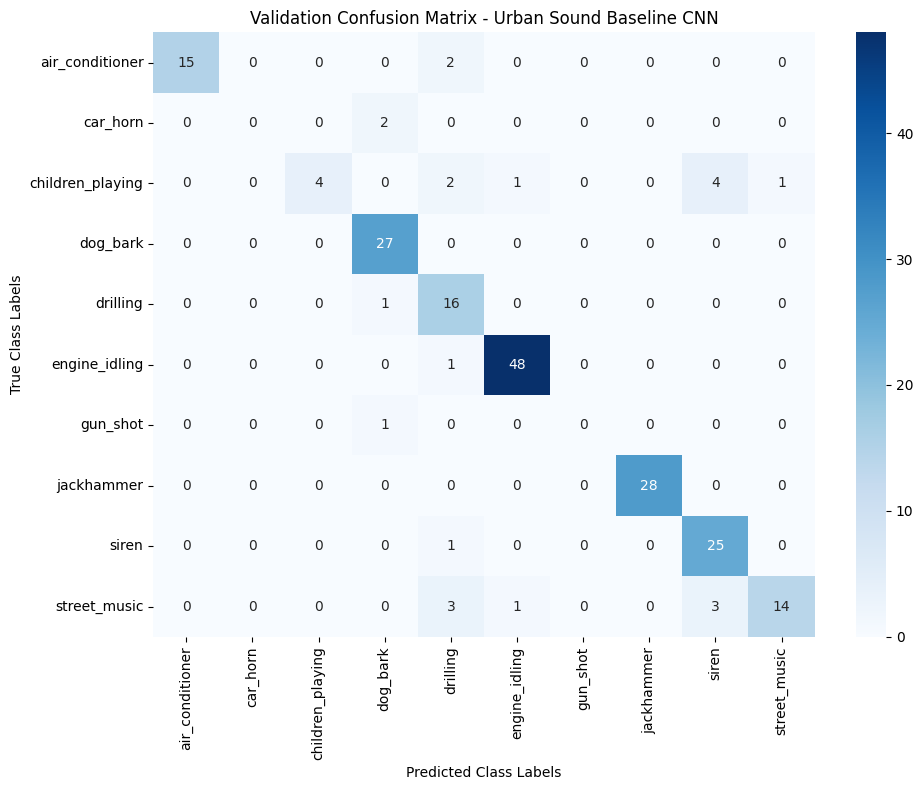

In [ ]:
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

# 1. Switch model to evaluation mode (disables dropout and batchnorm updates)
model.eval()

all_preds = []
all_labels = []

# 2. Collect all predictions from the validation set loader
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

# 3. Textual class names matching the UrbanSound8K dataset taxonomy
class_names = ['air_conditioner', 'car_horn', 'children_playing', 'dog_bark',
               'drilling', 'engine_idling', 'gun_shot', 'jackhammer', 'siren', 'street_music']

# 4. Print textual performance metrics per sound class
print("--- Classification Report ---")
print(classification_report(all_labels, all_preds, target_names=class_names))

# 5. Compute and plot the Confusion Matrix Heatmap
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Validation Confusion Matrix - Urban Sound Baseline CNN')
plt.ylabel('True Class Labels')
plt.xlabel('Predicted Class Labels')
plt.tight_layout()

# Save the plot directly to your cloud workspace so you can download it for GitHub
plt.savefig('confusion_matrix.png', dpi=300)
plt.show()

# Performance Evaluation & Metrics Analysis

The CNN model was evaluated using a held-out validation dataset after completing the training process. Performance was measured using validation accuracy, Precision, Recall, F1-score, and the Confusion Matrix to assess both overall and class-specific performance.

## Overall Performance

- Validation Accuracy: **88.50%**
- Training Accuracy: **84.00%**
- Evaluation Metrics:
  - Precision
  - Recall
  - F1-score
  - Confusion Matrix

An overall validation accuracy of **88.50%** indicates that the CNN learned meaningful acoustic patterns from the Log-Mel Spectrograms and generalized well to unseen audio samples.

---

## Class-wise Performance Analysis

### 1. Strong Performance on Continuous Mechanical Sounds

The model performed exceptionally well on sounds with stable frequency patterns such as:

- Engine Idling
- Air Conditioner
- Dog Bark

These sounds produce consistent acoustic signatures, making them easier for the convolutional filters to recognize.

---

### 2. Moderate Performance on Complex Urban Sounds

Classes such as:

- Drilling
- Street Music
- Siren

were classified reasonably well but occasionally confused with acoustically similar classes. These sounds contain richer frequency variations and overlapping environmental noise.

---

### 3. Weak Performance on Underrepresented Classes

The model struggled with classes including:

- Car Horn
- Gun Shot
- Children Playing

Possible reasons include:

- Very small number of validation samples
- High similarity to other urban sounds
- Large variations in pitch, duration, and background noise

Increasing the dataset size or applying stronger data augmentation would likely improve performance for these classes.

---

## Confusion Matrix Interpretation

The Confusion Matrix provides a visual summary of the model's predictions.

- High values along the diagonal indicate correct classifications.
- Off-diagonal values represent misclassified audio samples.
- Most errors occurred between acoustically similar sound classes, which is expected in environmental sound classification tasks.

---

## Model Strengths

- Successfully learned meaningful features from Log-Mel Spectrograms.
- Achieved high overall validation accuracy.
- Generalized well despite training on a relatively small subset.
- Strong performance on continuous mechanical sounds.

---

## Model Limitations

- Performance decreases for classes with limited training examples.
- Environmental background noise can confuse similar sound categories.
- Using only 1,000 samples limits the model's learning capacity.

---

## Recommendations for Future Improvements

Future work could improve performance by:

- Training on the complete UrbanSound8K dataset.
- Applying audio data augmentation (time shifting, noise injection, pitch shifting).
- Training for more epochs with Early Stopping.
- Using transfer learning models such as EfficientNet or ResNet.
- Performing hyperparameter tuning.
- Applying K-Fold Cross Validation for more robust evaluation.

---

# Conclusion

The proposed CNN-based audio classification system achieved a validation accuracy of **88.50%**, demonstrating that Convolutional Neural Networks can effectively classify urban environmental sounds using Log-Mel Spectrogram features.

Although some sound classes remain challenging due to limited data and acoustic similarity, the overall results indicate that the model successfully learned discriminative audio features and provides a strong baseline for future improvements. With additional data, augmentation techniques, and deeper neural network architectures, even higher classification performance can be achieved.

# Key Takeaways

- Converted raw audio into Log-Mel Spectrograms.
- Built a complete CNN architecture using PyTorch.
- Achieved 88.50% validation accuracy.
- Evaluated the model using Precision, Recall, F1-score, and Confusion Matrix.
- Saved the trained model for future deployment with Streamlit.
- Demonstrated a complete end-to-end Deep Learning audio classification pipeline.